# NCA Kaggle Dataset — Exploratory Data Analysis

**Dataset:** NCR18650B cylindrical cells (NCA chemistry, 3.4 Ah rated)  
**Source:** Dubarry et al., *J. Electrochem. Soc.* 2020 — [DOI:10.1149/1945-7111/abc8c0](https://iopscience.iop.org/article/10.1149/1945-7111/abc8c0)

**Experimental design:**
- **Operating window:** Normal [2.7–4.2 V], C/2 charge and discharge
- **Capacity Fade (CF) targets (cell grouping for the paper experiments):** N10 (10%), N15 (15%), N20 (20%)
- **Abuse groups (other cell grouping discret dimension with experiment cycling regime):** NA (no abuse), OV (overcharge), EX (external short)

**Columns in each CSV:**

| Column | Description |
|--------|-------------|
| `cycle` | Cycle index |
| `t_s` | Cumulative time (s) since experiment start |
| `current_a` | Current (A) — positive = charge, negative = discharge |
| `voltage_v` | Terminal voltage (V) |
| `charge_capacity_ah` | Cumulative charge capacity this cycle (Ah) |
| `discharge_capacity_ah` | Cumulative discharge capacity this cycle (Ah) |
| `sequence_order` | Global row index |

In [1]:
import re
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Set up plotting style
plt.rcParams.update({

    # dpi is the resolution of the figure, higher means sharper but larger file size
    'figure.dpi': 120,

    'font.size': 11,

    # Remove top and right spines for a cleaner look
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_DIR = Path('datasets/NCA_Kaggle/time_series')
RATED_CAPACITY = 3.4  # Ah, manufacturer-rated

# Get all the CSV files in the data directory and print their names by alphabetical order
CSV_FILES = sorted(DATA_DIR.glob('*.csv'))
print(f'Found {len(CSV_FILES)} files:')
for f in CSV_FILES:
    print(' ', f.name)

Found 11 files:
  OV8_3cycles.csv
  UL-PUR_N10-EX9_18650_NCA_23C_0-100_0.5-0.5C_i.csv
  UL-PUR_N10-NA7_18650_NCA_23C_0-100_0.5-0.5C_g.csv
  UL-PUR_N10-OV8_18650_NCA_23C_0-100_0.5-0.5C_h.csv
  UL-PUR_N15-EX4_18650_NCA_23C_0-100_0.5-0.5C_d.csv
  UL-PUR_N15-NA10_18650_NCA_23C_0-100_0.5-0.5C_j.csv
  UL-PUR_N15-OV3_18650_NCA_23C_0-100_0.5-0.5C_c.csv
  UL-PUR_N20-EX2_18650_NCA_23C_0-100_0.5-0.5C_b.csv
  UL-PUR_N20-NA5_18650_NCA_23C_0-100_0.5-0.5C_e.csv
  UL-PUR_N20-NA6_18650_NCA_23C_0-100_0.5-0.5C_f.csv
  UL-PUR_N20-OV1_18650_NCA_23C_0-100_0.5-0.5C_a.csv


## 1. Load data, parse metadata and stat summary

In [2]:
# This function extracts the capacity fade target number (after the N) and the abuse group label from the file name, 
# and creates an id with the 2, that is also returned
def parse_filename(name: str) -> dict:
    m = re.search(r'N(\d+)-(EX|NA|OV)(\d+)', name)
    if not m:
        return {}
    return {
        'cf_pct': int(m.group(1)),
        'abuse': m.group(2),
        'cell_id': m.group(2) + m.group(3),
    }

dfs = {}
meta_rows = []

# for each csv file, print important information
for path in CSV_FILES:
    df = pd.read_csv(path)
    info = parse_filename(path.name)
    if not info:
        print(f"WARNING: skipping {path.name} — doesn't match expected pattern N<n>-(EX|NA|OV)<n>")
        continue
    label = info['cell_id']
    df['cell'] = label
    df['cf_pct'] = info['cf_pct']
    df['abuse'] = info['abuse']
    dfs[label] = df


    per_cycle = df.groupby('cycle').agg(
        q_charge=('charge_capacity_ah', 'max'),
        q_discharge=('discharge_capacity_ah', 'max'),
    ).reset_index()

    meta_rows.append({
        'cell': label,
        'cf_target_%': info['cf_pct'],
        'abuse_group': info['abuse'],
        'n_cycles': int(df['cycle'].max()),
        'n_rows': len(df),
        'Q_initial_Ah': round(per_cycle['q_discharge'].iloc[0], 4),
        'Q_final_Ah': round(per_cycle['q_discharge'].iloc[-1], 4),
        'SoH_final_%': round(per_cycle['q_discharge'].iloc[-1] / per_cycle['q_discharge'].iloc[0] * 100, 1),
        'actual_fade_%': round((1 - per_cycle['q_discharge'].iloc[-1] / per_cycle['q_discharge'].iloc[0]) * 100, 1),
    })

meta = pd.DataFrame(meta_rows).sort_values(['cf_target_%', 'abuse_group']).reset_index(drop=True)


summary = meta.copy()
summary['total_time_days'] = [
    round(dfs[c]['t_s'].max() / 86400, 1) for c in summary['cell']
]
summary['mean_Q_Ah'] = [
    round(dfs[c].groupby('cycle')['discharge_capacity_ah'].max().mean(), 4)
    for c in summary['cell']
]
summary['std_Q_Ah'] = [
    round(dfs[c].groupby('cycle')['discharge_capacity_ah'].max().std(), 4)
    for c in summary['cell']
]

print('=== Dataset summary ===')
print(f'Total rows:  {sum(len(d) for d in dfs.values()):>10,}')
print(f'Total cells: {len(dfs):>10}')
print(f'Cycle range: {min(d["cycle"].max() for d in dfs.values())} – {max(d["cycle"].max() for d in dfs.values())}')
print()

display(summary)

=== Dataset summary ===
Total rows:     387,102
Total cells:         10
Cycle range: 124 – 255



,cell,cf_target_%,abuse_group,n_cycles,n_rows,Q_initial_Ah,Q_final_Ah,SoH_final_%,actual_fade_%,total_time_days,mean_Q_Ah,std_Q_Ah
0,EX9,10,EX,124,27262,3.299,2.801,84.9,15.1,43.6,3.0093,0.1815
1,NA7,10,NA,127,25613,3.012,2.721,90.3,9.7,33.3,2.8424,0.0691
2,OV8,10,OV,137,30249,3.295,2.766,83.9,16.1,44.1,2.9708,0.1922
3,EX4,15,EX,160,36330,3.301,2.725,82.6,17.4,53.2,3.1733,0.1663
4,NA10,15,NA,194,39117,3.134,2.729,87.1,12.9,54.2,2.9333,0.1296
5,OV3,15,OV,152,34570,3.274,2.702,82.5,17.5,45.3,3.1722,0.1384
6,EX2,20,EX,255,65072,3.344,2.439,72.9,27.1,84.9,3.1367,0.1450
7,NA5,20,NA,154,35630,3.334,2.670,80.1,19.9,46.1,3.1603,0.2135
8,NA6,20,NA,160,37243,3.315,2.562,77.3,22.7,50.1,3.1211,0.2307
9,OV1,20,OV,209,56016,3.259,2.495,76.6,23.4,82.6,3.0725,0.1274


## 2. Number of cycles

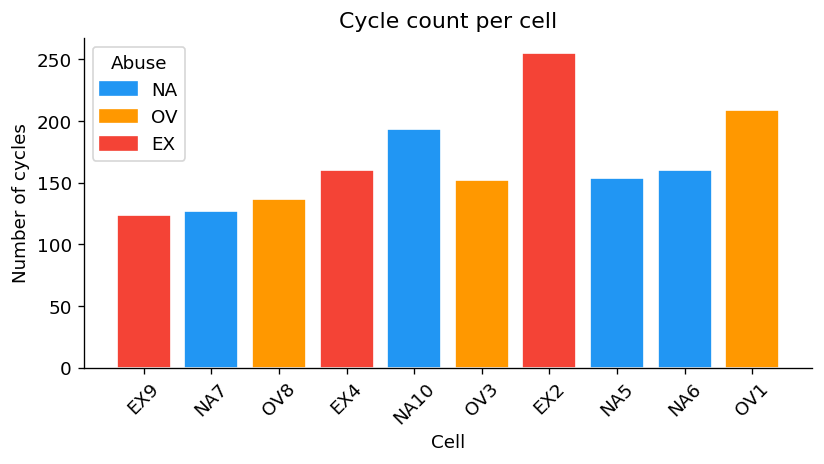

In [3]:
palette = {'NA': '#2196F3', 'OV': '#FF9800', 'EX': '#F44336'}

fig, ax = plt.subplots(figsize=(7, 4))

for _, row in meta.iterrows():
    ax.bar(row['cell'], row['n_cycles'], color=palette[row['abuse_group']], edgecolor='white')
ax.set_xlabel('Cell')
ax.set_ylabel('Number of cycles')
ax.set_title('Cycle count per cell')
ax.tick_params(axis='x', rotation=45)
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend_handles, title='Abuse')

fig.tight_layout()
plt.show()

## 3. Capacity fade and SoH evolution

### 3.1 Initial VS final capacity

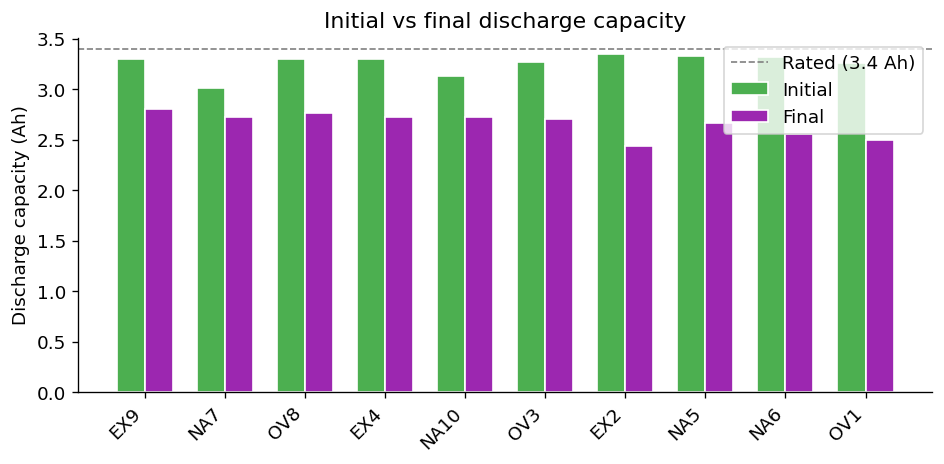

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(meta))
width = 0.35
ax.bar(x - width/2, meta['Q_initial_Ah'], width, label='Initial', color='#4CAF50', edgecolor='white')
ax.bar(x + width/2, meta['Q_final_Ah'], width, label='Final', color='#9C27B0', edgecolor='white')
ax.axhline(RATED_CAPACITY, color='gray', linestyle='--', lw=1, label=f'Rated ({RATED_CAPACITY} Ah)')
ax.set_xticks(x)
ax.set_xticklabels(meta['cell'], rotation=45, ha='right')
ax.set_ylabel('Discharge capacity (Ah)')
ax.set_title('Initial vs final discharge capacity')
ax.legend()

fig.tight_layout()
plt.show()

### 3.2 Continual Capacity fade

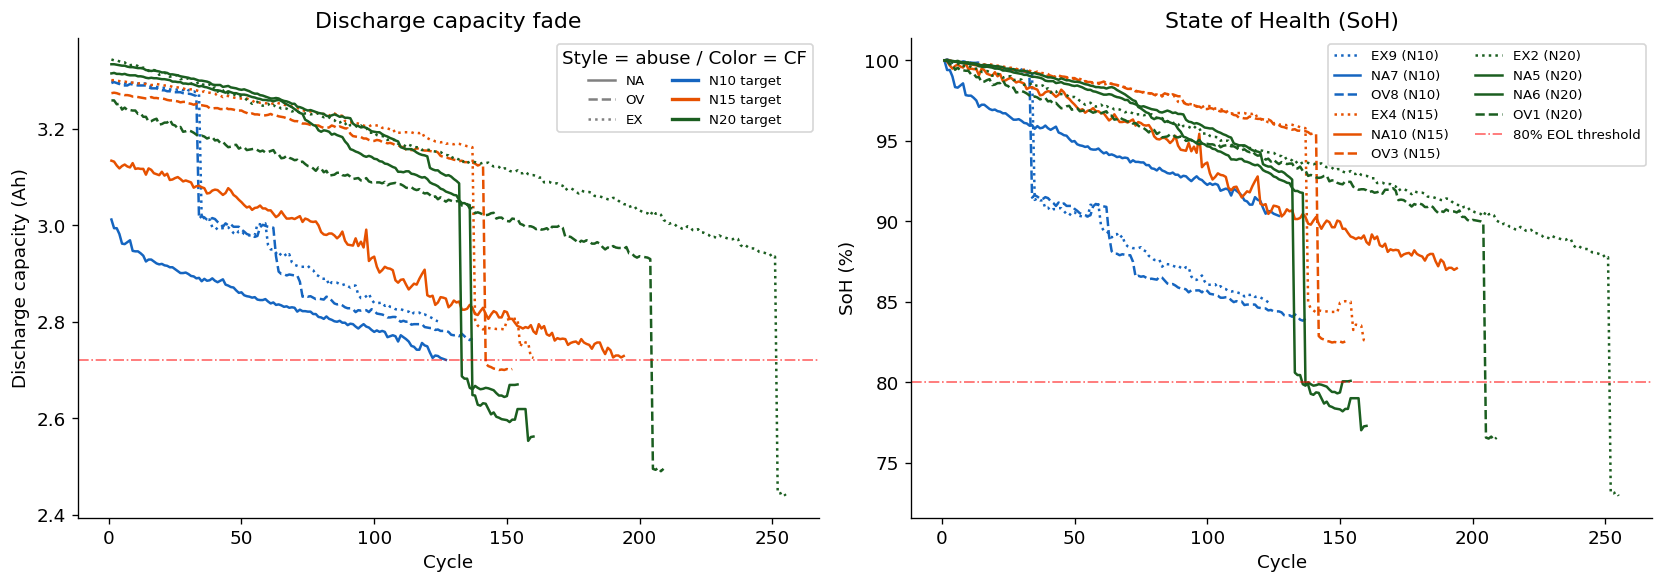

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

linestyles = {'NA': '-', 'OV': '--', 'EX': ':'}
colors_cf = {10: '#1565C0', 15: '#E65100', 20: '#1B5E20'}

for label, df in dfs.items():
    row = meta[meta['cell'] == label].iloc[0]
    per_cycle = df.groupby('cycle')['discharge_capacity_ah'].max().reset_index()
    soh = per_cycle['discharge_capacity_ah'] / per_cycle['discharge_capacity_ah'].iloc[0] * 100

    color = colors_cf[row['cf_target_%']]
    ls = linestyles[row['abuse_group']]

    axes[0].plot(per_cycle['cycle'], per_cycle['discharge_capacity_ah'],
                 lw=1.5, ls=ls, color=color, label=f"{label} (N{row['cf_target_%']})")
    axes[1].plot(per_cycle['cycle'], soh,
                 lw=1.5, ls=ls, color=color, label=f"{label} (N{row['cf_target_%']})")

for ax, ylabel, eol in [
    (axes[0], 'Discharge capacity (Ah)', RATED_CAPACITY * 0.8),
    (axes[1], 'SoH (%)', 80),
]:
    ax.axhline(eol, color='red', lw=1, ls='-.', alpha=0.6, label='80% EOL threshold')
    ax.set_xlabel('Cycle')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, ncol=2)

axes[0].set_title('Discharge capacity fade')
axes[1].set_title('State of Health (SoH)')

from matplotlib.lines import Line2D
ls_handles = [Line2D([0], [0], ls=ls, color='gray', lw=1.5, label=ab)
              for ab, ls in linestyles.items()]
cf_handles = [Line2D([0], [0], ls='-', color=c, lw=2, label=f'N{cf} target')
              for cf, c in colors_cf.items()]
axes[0].legend(handles=ls_handles + cf_handles, title='Style = abuse / Color = CF', fontsize=8, ncol=2)

fig.tight_layout()
plt.show()

## 4. Voltage and current profiles

### 4.1 Single cycle sample

/home/orfeu/pip-tmp/ipykernel_36075/303249578.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', len(cycles_to_plot))


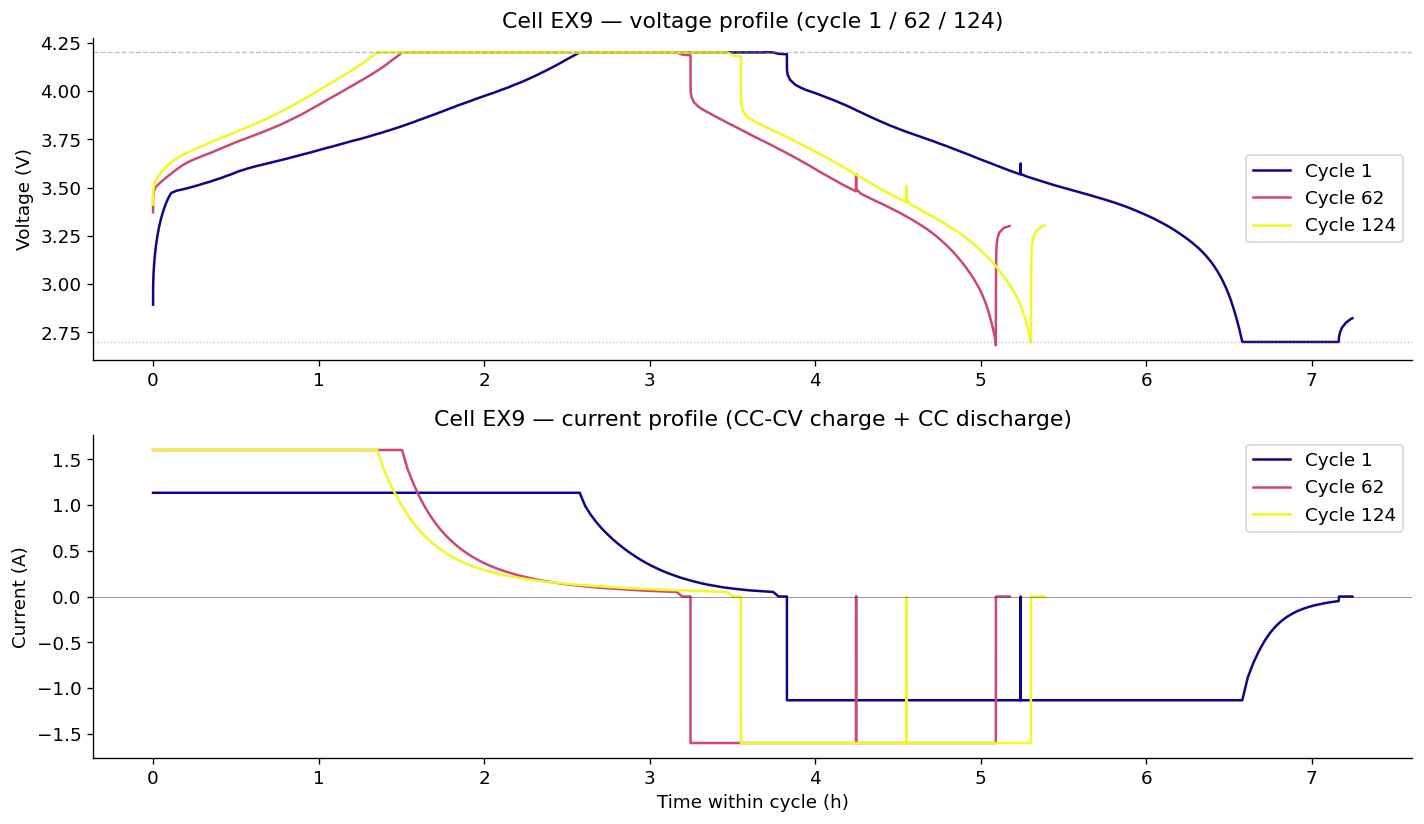

In [6]:
# Use one fresh cell as reference (N10-EX)
ref_cell = 'EX9'
df_ref = dfs[ref_cell]

n_last = int(df_ref['cycle'].max())
n_mid = n_last // 2
cycles_to_plot = [1, n_mid, n_last]

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

cmap = cm.get_cmap('plasma', len(cycles_to_plot))
for i, cyc in enumerate(cycles_to_plot):
    cyc_df = df_ref[df_ref['cycle'] == cyc].copy()
    t_h = (cyc_df['t_s'] - cyc_df['t_s'].iloc[0]) / 3600
    color = cmap(i)
    axes[0].plot(t_h, cyc_df['voltage_v'], color=color, lw=1.5, label=f'Cycle {cyc}')
    axes[1].plot(t_h, cyc_df['current_a'], color=color, lw=1.5, label=f'Cycle {cyc}')

axes[0].axhline(4.2, color='gray', lw=0.8, ls='--', alpha=0.5)
axes[0].axhline(2.7, color='gray', lw=0.8, ls=':', alpha=0.5)
axes[0].set_ylabel('Voltage (V)')
axes[0].set_title(f'Cell {ref_cell} — voltage profile (cycle 1 / {n_mid} / {n_last})')
axes[0].legend()

axes[1].axhline(0, color='black', lw=0.6, alpha=0.4)
axes[1].set_ylabel('Current (A)')
axes[1].set_xlabel('Time within cycle (h)')
axes[1].set_title(f'Cell {ref_cell} — current profile (CC-CV charge + CC discharge)')
axes[1].legend()

fig.tight_layout()
plt.show()

### 4.2 All cycles sample

In [8]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

CELL_ID = 'OV8'  # change to any: EX9, NA7, OV8, EX4, NA10, OV3, EX2, NA5, NA6, OV1
X_AXIS  = 'time' # 'time'  → cumulative hours
                  # 'cycle' → cycle number (each cycle spans exactly 1 unit)

df_plot = dfs[CELL_ID].copy()

if X_AXIS == 'cycle':
    t_min   = df_plot.groupby('cycle')['t_s'].transform('min')
    t_max   = df_plot.groupby('cycle')['t_s'].transform('max')
    t_range = (t_max - t_min).replace(0, 1)
    df_plot['x'] = df_plot['cycle'] + (df_plot['t_s'] - t_min) / t_range
    x_col   = 'x'
    x_label = 'Cycle number'
else:
    df_plot['x'] = df_plot['t_s'] / 3600
    x_col   = 'x'
    x_label = 'Cumulative time (h)'

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    row_heights=[0.6, 0.4],
)

fig.add_trace(go.Scattergl(
    x=df_plot[x_col], y=df_plot['voltage_v'],
    mode='markers', marker=dict(size=2, color='steelblue', opacity=0.5),
    name='Voltage (V)',
), row=1, col=1)

fig.add_trace(go.Scattergl(
    x=df_plot[x_col], y=df_plot['current_a'],
    mode='markers', marker=dict(size=2, color='tomato', opacity=0.5),
    name='Current (A)',
), row=2, col=1)

fig.add_hline(y=4.2, line_dash='dash', line_color='gray', opacity=0.4,
              annotation_text='4.2 V', row=1, col=1)
fig.add_hline(y=2.7, line_dash='dot', line_color='gray', opacity=0.4,
              annotation_text='2.7 V', row=1, col=1)
fig.add_hline(y=0, line_dash='dot', line_color='black', opacity=0.3, row=2, col=1)

fig.update_layout(
    title=f'Full time series — Cell {CELL_ID} ({len(df_plot):,} points)',
    hovermode='x unified',
    template='simple_white',
    height=600,
)

fig.update_yaxes(title_text='Voltage (V)', row=1, col=1)
fig.update_yaxes(title_text='Current (A)', row=2, col=1)
fig.update_xaxes(title_text=x_label, row=2, col=1)

fig.show()

## 5. Voltage–Capacity (V-Q) profiles

/home/orfeu/pip-tmp/ipykernel_4544/2056196891.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(cycles_to_plot))


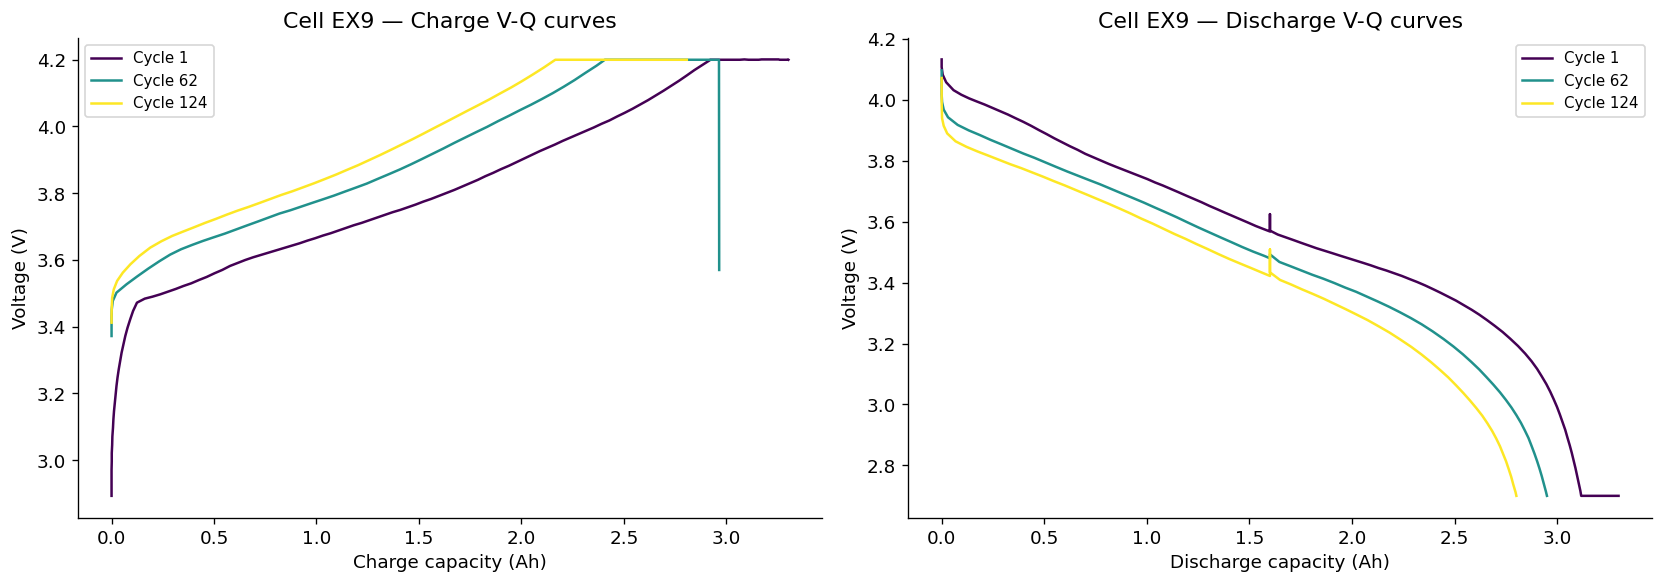

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap = cm.get_cmap('viridis', len(cycles_to_plot))
for i, cyc in enumerate(cycles_to_plot):
    cyc_df = df_ref[df_ref['cycle'] == cyc]
    color = cmap(i)

    chg = cyc_df[cyc_df['current_a'] > 0]
    if not chg.empty:
        axes[0].plot(chg['charge_capacity_ah'], chg['voltage_v'],
                     color=color, lw=1.5, label=f'Cycle {cyc}')

    dch = cyc_df[cyc_df['current_a'] < 0]
    if not dch.empty:
        axes[1].plot(dch['discharge_capacity_ah'], dch['voltage_v'],
                     color=color, lw=1.5, label=f'Cycle {cyc}')

for ax, title, xlabel in [
    (axes[0], 'Charge V-Q curves', 'Charge capacity (Ah)'),
    (axes[1], 'Discharge V-Q curves', 'Discharge capacity (Ah)'),
]:
    ax.set_title(f'Cell {ref_cell} — {title}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Voltage (V)')
    ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## 6. SoH evolution grouped by CF target and abuse type

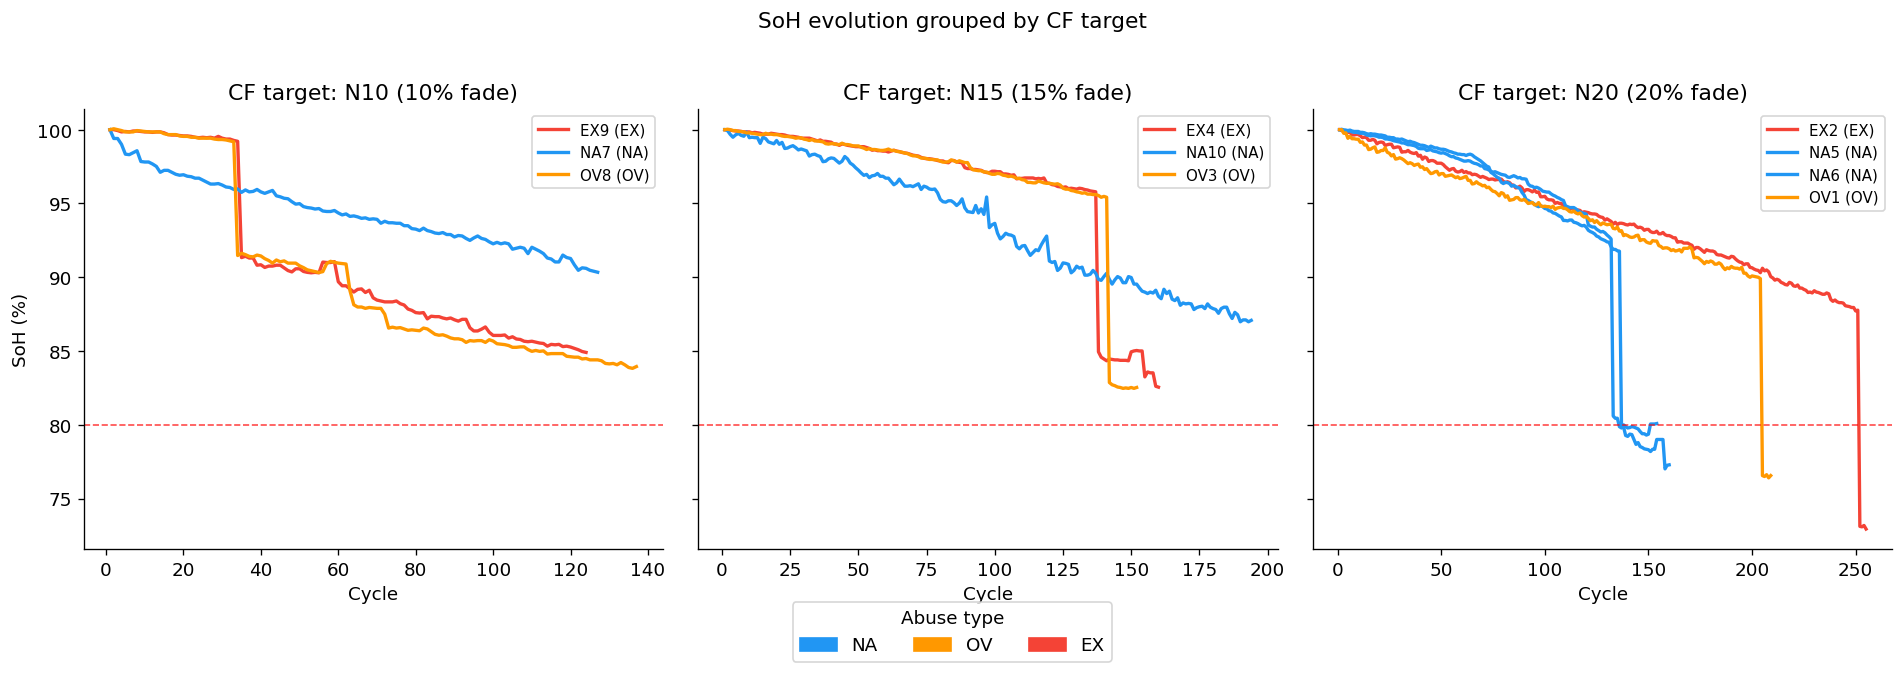

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
cf_levels = [10, 15, 20]
abuse_colors = {'NA': '#2196F3', 'OV': '#FF9800', 'EX': '#F44336'}

for ax, cf in zip(axes, cf_levels):
    group_cells = meta[meta['cf_target_%'] == cf]['cell'].tolist()
    for cell in group_cells:
        df_c = dfs[cell]
        abuse = meta[meta['cell'] == cell]['abuse_group'].values[0]
        per_cycle = df_c.groupby('cycle')['discharge_capacity_ah'].max()
        soh = per_cycle / per_cycle.iloc[0] * 100
        ax.plot(soh.index, soh.values, lw=2, color=abuse_colors[abuse], label=f'{cell} ({abuse})')

    ax.axhline(80, color='red', lw=1, ls='--', alpha=0.7)
    ax.set_title(f'CF target: N{cf} ({cf}% fade)')
    ax.set_xlabel('Cycle')
    ax.legend(fontsize=9)

axes[0].set_ylabel('SoH (%)')

from matplotlib.patches import Patch
handles = [Patch(color=c, label=l) for l, c in abuse_colors.items()]
fig.legend(handles=handles, title='Abuse type', loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08))

fig.suptitle('SoH evolution grouped by CF target', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 7. Capacity distribution — violin plots

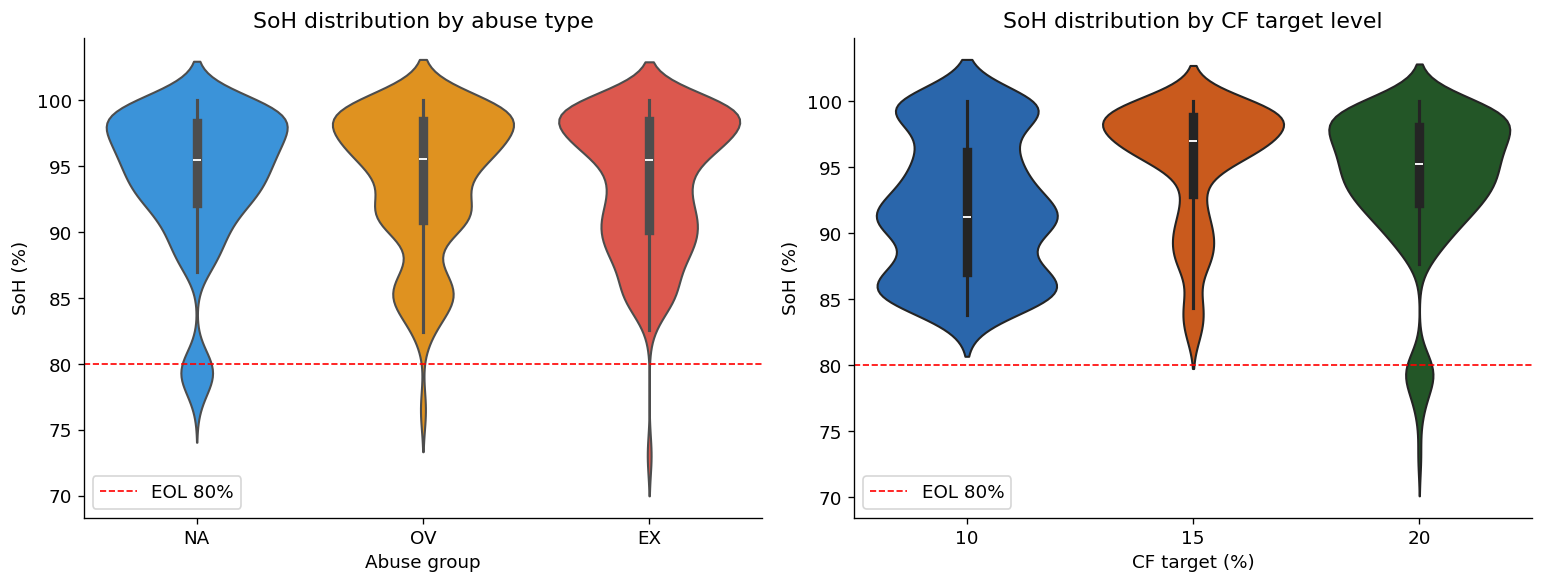

In [ ]:
records = []
for label, df in dfs.items():
    m = meta[meta['cell'] == label].iloc[0]
    per_cycle = df.groupby('cycle')['discharge_capacity_ah'].max().reset_index()
    per_cycle['cell'] = label
    per_cycle['cf_pct'] = m['cf_target_%']
    per_cycle['abuse'] = m['abuse_group']
    per_cycle['soh'] = per_cycle['discharge_capacity_ah'] / per_cycle['discharge_capacity_ah'].iloc[0] * 100
    records.append(per_cycle)

all_cycles = pd.concat(records, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(
    data=all_cycles, x='abuse', y='soh', hue='abuse',
    palette=abuse_colors, inner='box', order=['NA', 'OV', 'EX'],
    legend=False, ax=axes[0]
)
axes[0].axhline(80, color='red', ls='--', lw=1, label='EOL 80%')
axes[0].set_title('SoH distribution by abuse type')
axes[0].set_xlabel('Abuse group')
axes[0].set_ylabel('SoH (%)')
axes[0].legend()

cf_palette = {'10': '#1565C0', '15': '#E65100', '20': '#1B5E20'}
sns.violinplot(
    data=all_cycles.assign(cf_pct=all_cycles['cf_pct'].astype(str)),
    x='cf_pct', y='soh', hue='cf_pct',
    palette=cf_palette, inner='box', order=['10', '15', '20'],
    legend=False, ax=axes[1]
)
axes[1].axhline(80, color='red', ls='--', lw=1, label='EOL 80%')
axes[1].set_title('SoH distribution by CF target level')
axes[1].set_xlabel('CF target (%)')
axes[1].set_ylabel('SoH (%)')
axes[1].legend()

fig.tight_layout()
plt.show()

## 8. Differential capacity analysis (dQ/dV)

The dQ/dV curve reveals electrochemical phase transitions as peaks. Shifting or attenuating peaks indicate degradation mechanisms (loss of active material, lithium inventory loss).

/home/orfeu/pip-tmp/ipykernel_4544/1276661374.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap4 = cm.get_cmap('plasma', len(plot_cycles))


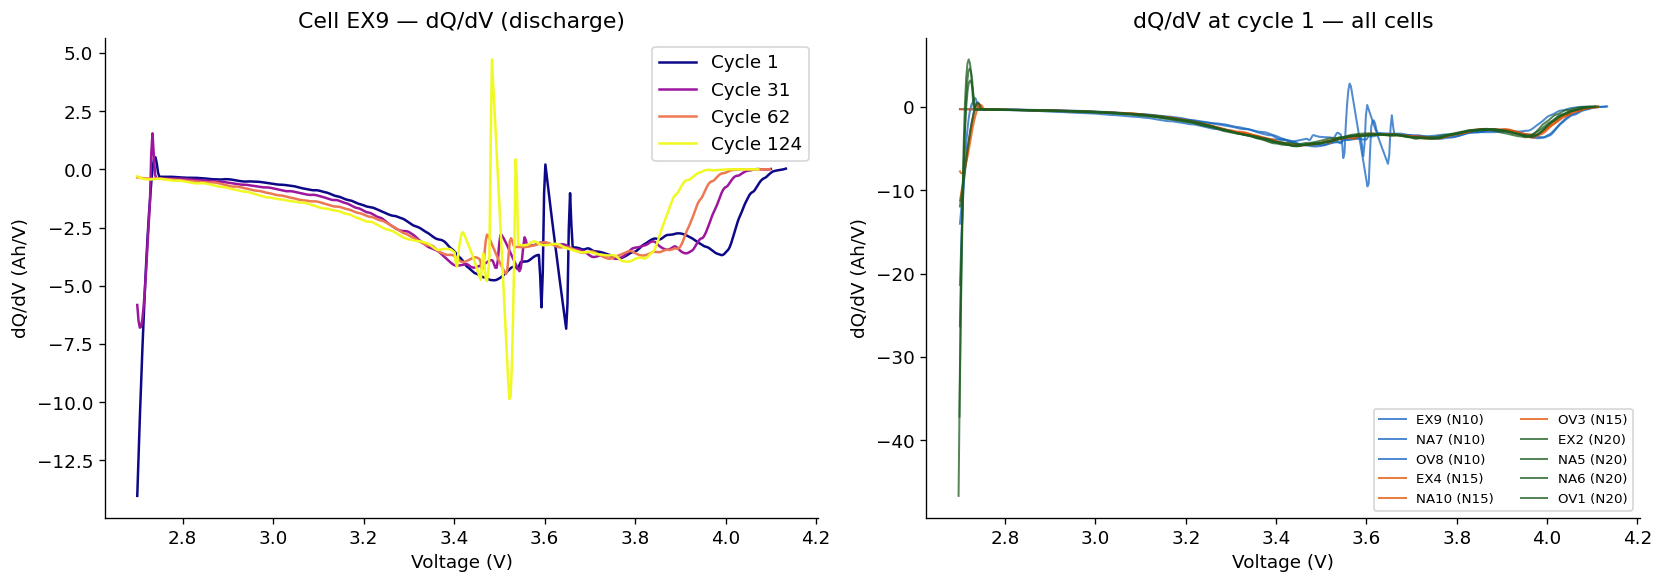

In [ ]:
from scipy.signal import savgol_filter

def compute_dqdv(df_cycle, n_points=500):
    dch = df_cycle[df_cycle['current_a'] < 0].copy()
    dch = dch.sort_values('voltage_v').drop_duplicates('voltage_v')
    if len(dch) < 20:
        return None, None
    v_grid = np.linspace(dch['voltage_v'].min(), dch['voltage_v'].max(), n_points)
    q_interp = np.interp(v_grid, dch['voltage_v'], dch['discharge_capacity_ah'])
    dqdv = np.gradient(q_interp, v_grid)
    return v_grid, savgol_filter(dqdv, window_length=21, polyorder=3)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# dQ/dV evolution across life for the reference cell
plot_cycles = [1, n_mid // 2, n_mid, n_last]
cmap4 = cm.get_cmap('plasma', len(plot_cycles))
for i, cyc in enumerate(plot_cycles):
    v, dqdv = compute_dqdv(df_ref[df_ref['cycle'] == cyc])
    if v is not None:
        axes[0].plot(v, dqdv, color=cmap4(i), lw=1.5, label=f'Cycle {cyc}')

axes[0].set_title(f'Cell {ref_cell} — dQ/dV (discharge)')
axes[0].set_xlabel('Voltage (V)')
axes[0].set_ylabel('dQ/dV (Ah/V)')
axes[0].legend()

# dQ/dV at cycle 1 across all cells
cf_palette = {10: '#1565C0', 15: '#E65100', 20: '#1B5E20'}
for label, df_c in dfs.items():
    row = meta[meta['cell'] == label].iloc[0]
    v, dqdv = compute_dqdv(df_c[df_c['cycle'] == 1])
    if v is not None:
        axes[1].plot(v, dqdv, color=cf_palette[row['cf_target_%']],
                     lw=1.2, alpha=0.75, label=f"{label} (N{row['cf_target_%']})")

axes[1].set_title('dQ/dV at cycle 1 — all cells')
axes[1].set_xlabel('Voltage (V)')
axes[1].set_ylabel('dQ/dV (Ah/V)')
axes[1].legend(fontsize=8, ncol=2)

fig.tight_layout()
plt.show()

## 9. Cycle duration and CV-phase duration

As cells age, increased internal resistance can affect the duration of the constant-voltage (CV) taper phase. Longer CV taper or shorter overall cycle time may indicate degradation.

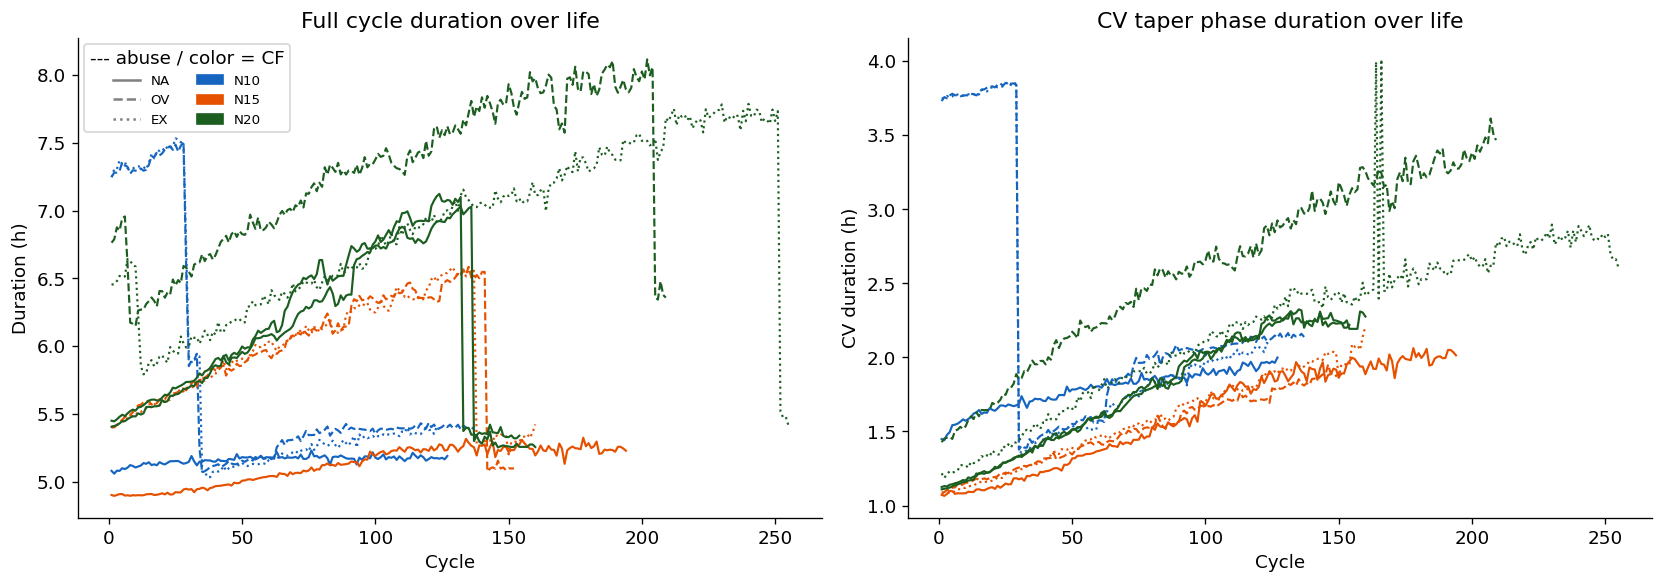

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

linestyles = {'NA': '-', 'OV': '--', 'EX': ':'}
colors_cf = {10: '#1565C0', 15: '#E65100', 20: '#1B5E20'}

for label, df_c in dfs.items():
    row = meta[meta['cell'] == label].iloc[0]
    color = colors_cf[row['cf_target_%']]
    ls = linestyles[row['abuse_group']]

    # Total cycle duration
    cyc_time = df_c.groupby('cycle')['t_s'].agg(lambda x: (x.max() - x.min()) / 3600)
    axes[0].plot(cyc_time.index, cyc_time.values, lw=1.3, ls=ls, color=color, label=label)

    # CV taper duration (charging with current tapering below C/2)
    cv_rows = df_c[(df_c['current_a'] > 0.01) & (df_c['current_a'] < 1.5)]
    if not cv_rows.empty:
        cv_time = cv_rows.groupby('cycle')['t_s'].agg(lambda x: (x.max() - x.min()) / 3600)
        axes[1].plot(cv_time.index, cv_time.values, lw=1.3, ls=ls, color=color, label=label)

for ax, title, ylabel in [
    (axes[0], 'Full cycle duration over life', 'Duration (h)'),
    (axes[1], 'CV taper phase duration over life', 'CV duration (h)'),
]:
    ax.set_title(title)
    ax.set_xlabel('Cycle')
    ax.set_ylabel(ylabel)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
style_handles = [Line2D([0], [0], ls=ls, color='gray', lw=1.5, label=ab)
                 for ab, ls in linestyles.items()]
color_handles = [Patch(color=c, label=f'N{cf}') for cf, c in colors_cf.items()]
axes[0].legend(handles=style_handles + color_handles, fontsize=8, ncol=2, title='--- abuse / color = CF')

fig.tight_layout()
plt.show()

### 9.1 Rest duration

In [ ]:
REST_THRESHOLD_A = 0.5  # |current| below this is considered rest

rest_rows = []
rest_durations_all = []  # long-form for boxplot

for label, df_c in dfs.items():
    m = meta[meta['cell'] == label].iloc[0]
    is_rest = df_c['current_a'].abs() < REST_THRESHOLD_A
    seg_id = (is_rest != is_rest.shift()).cumsum()

    rest_durations_s = df_c[is_rest].groupby(seg_id[is_rest])['t_s'].agg(lambda x: x.max() - x.min())
    active_durations_s = df_c[~is_rest].groupby(seg_id[~is_rest])['t_s'].agg(lambda x: x.max() - x.min())
    total_time_s = df_c['t_s'].max() - df_c['t_s'].min()

    rest_rows.append({
        'cell': label,
        'cf_%': m['cf_target_%'],
        'abuse': m['abuse_group'],
        'n_rest_periods': len(rest_durations_s),
        'rest_freq_min': round(total_time_s / 60 / len(rest_durations_s), 1),
        'longest_no_rest_min': round(active_durations_s.max() / 60, 1),
    })

    for d in rest_durations_s:
        rest_durations_all.append({
            'cell': label,
            'cf_%': m['cf_target_%'],
            'abuse': m['abuse_group'],
            'duration_min': d / 60,
        })

rest_summary = pd.DataFrame(rest_rows).sort_values(['cf_%', 'abuse']).reset_index(drop=True)
rest_durations_df = pd.DataFrame(rest_durations_all)

print(f'Rest threshold: |current| < {REST_THRESHOLD_A} A')
display(rest_summary)

Rest threshold: |current| < 0.5 A


,cell,cf_%,abuse,n_rest_periods,rest_freq_min,longest_no_rest_min
0,EX9,10,EX,379,165.8,170.8
1,NA7,10,NA,384,125.0,114.8
2,OV8,10,OV,412,154.1,170.6
3,EX4,15,EX,415,184.4,127.4
4,NA10,15,NA,591,132.1,120.3
5,OV3,15,OV,391,166.8,127.0
6,EX2,20,EX,556,219.9,130.4
7,NA5,20,NA,401,165.4,129.2
8,NA6,20,NA,421,171.5,128.3
9,OV1,20,OV,456,261.0,130.9


/home/orfeu/pip-tmp/ipykernel_4544/1605623631.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


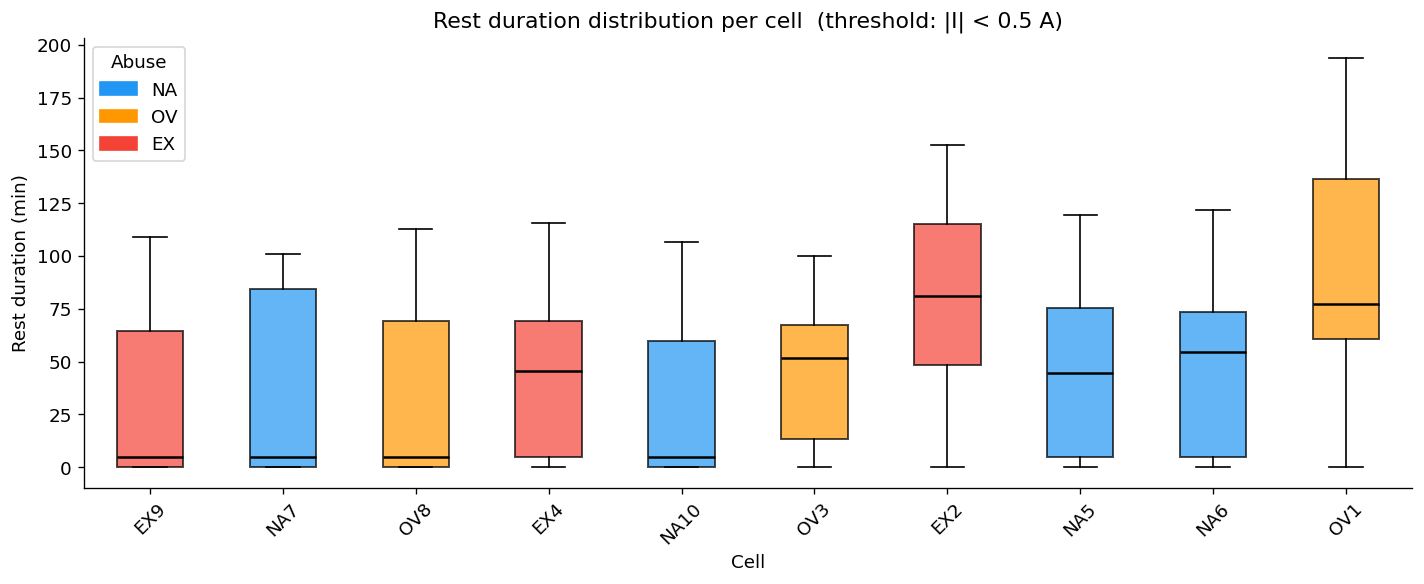

In [ ]:
cell_order = rest_summary['cell'].tolist()
abuse_colors = {'NA': '#2196F3', 'OV': '#FF9800', 'EX': '#F44336'}
colors = [abuse_colors[rest_summary.set_index('cell').loc[c, 'abuse']] for c in cell_order]

fig, ax = plt.subplots(figsize=(12, 5))

ax.boxplot(
    [rest_durations_df[rest_durations_df['cell'] == c]['duration_min'].values for c in cell_order],
    labels=cell_order,
    patch_artist=True,
    boxprops=dict(linewidth=1.2),
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
)

for patch, color in zip(ax.patches, colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l, c in abuse_colors.items()]
ax.legend(handles=legend_handles, title='Abuse')

ax.set_xlabel('Cell')
ax.set_ylabel('Rest duration (min)')
ax.set_title(f'Rest duration distribution per cell  (threshold: |I| < {REST_THRESHOLD_A} A)')
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

## 10. Sampling frequency and value quantization


In [ ]:
def quantization_step(series, n_decimals=8):
    """Smallest non-zero absolute difference between consecutive sorted unique values."""
    vals = np.sort(series.dropna().unique())
    diffs = np.diff(vals)
    nonzero = diffs[diffs > 0]
    return round(float(nonzero.min()), n_decimals) if len(nonzero) else np.nan

rows = []
for label, df_c in dfs.items():
    dt = df_c['t_s'].diff().dropna()
    rows.append({
        'cell': label,
        # --- Sampling frequency ---
        'median_dt_s':    round(dt.median(), 4),
        'mode_dt_s':      round(dt.mode().iloc[0], 4),
        'min_dt_s':       round(dt.min(), 4),
        'max_dt_s':       round(dt.max(), 4),
        'median_fs_hz':   round(1 / dt.median(), 4),
        # --- Value quantization ---
        'voltage_step_V':  quantization_step(df_c['voltage_v']),
        'current_step_A':  quantization_step(df_c['current_a']),
    })

acq = pd.DataFrame(rows)
print('=== Sampling & quantization per cell ===')
display(acq)

print('\n=== Cross-cell consensus ===')
for col in ['median_dt_s', 'mode_dt_s', 'median_fs_hz', 'voltage_step_V', 'current_step_A']:
    unique_vals = acq[col].unique()
    status = 'identical' if len(unique_vals) == 1 else f'{len(unique_vals)} distinct values'
    print(f'  {col:<22}: {status}  →  {unique_vals}')

=== Sampling & quantization per cell ===


,cell,median_dt_s,mode_dt_s,min_dt_s,max_dt_s,median_fs_hz,voltage_step_V,current_step_A
0,EX9,120.008,120.009,-3580.901,155288.238,0.0083,0.001,0.001
1,NA7,120.009,120.009,-3578.708,78085.340,0.0083,0.001,0.001
2,OV8,120.008,120.009,0.000,313518.046,0.0083,0.001,0.001
3,EX4,120.008,120.008,-3556.189,231948.969,0.0083,0.001,0.001
4,NA10,120.009,120.009,-3570.345,222729.153,0.0083,0.001,0.001
5,OV3,120.008,120.008,-3453.055,314925.398,0.0083,0.001,0.001
6,EX2,120.009,120.009,-3500.039,328377.960,0.0083,0.001,0.001
7,NA5,120.008,120.008,-3540.823,126459.663,0.0083,0.001,0.001
8,NA6,120.008,120.008,-3578.626,303733.466,0.0083,0.001,0.001
9,OV1,120.009,120.009,-3542.422,208900.149,0.0083,0.001,0.001



=== Cross-cell consensus ===
  median_dt_s           : 2 distinct values  →  [120.008 120.009]
  mode_dt_s             : 2 distinct values  →  [120.009 120.008]
  median_fs_hz          : identical  →  [0.0083]
  voltage_step_V        : identical  →  [0.001]
  current_step_A        : identical  →  [0.001]


In [ ]:
for label, df_c in dfs.items():
    resets = df_c.index[df_c['t_s'].diff() < 0].tolist()
    if resets:
        print(f'{label}: {len(resets)} reset(s) at row(s) {resets}')
    else:
        print(f'{label}: no resets')

EX9: 18 reset(s) at row(s) [9274, 9339, 9400, 9466, 9564, 9628, 13258, 13323, 13384, 13451, 13526, 13594, 14061, 14127, 14188, 14255, 14330, 14400]
NA7: 6 reset(s) at row(s) [4419, 4484, 4544, 4611, 4687, 4755]
OV8: no resets
EX4: 6 reset(s) at row(s) [34667, 34734, 34795, 34865, 34939, 35012]
NA10: 17 reset(s) at row(s) [9179, 10161, 12338, 13131, 14119, 30016, 30083, 30144, 30212, 30285, 30356, 38319, 38386, 38446, 38516, 38590, 38662]
OV3: 1 reset(s) at row(s) [14883]
EX2: 1 reset(s) at row(s) [6469]
NA5: 14 reset(s) at row(s) [12189, 29695, 31210, 31276, 31336, 31406, 31479, 31555, 35030, 35098, 35160, 35231, 35305, 35378]
NA6: 19 reset(s) at row(s) [30686, 35805, 35842, 35879, 35947, 35978, 36009, 36070, 36100, 36130, 36200, 36240, 36280, 36355, 36390, 36425, 36497, 36534, 36571]
OV1: 1 reset(s) at row(s) [17636]
